# Phase 0 — Feasibility: how accurately can we estimate food volume & mass?

This notebook measures the **baseline accuracy** of the volume-estimation method on
**ECUSTFD**, the public dataset that matches our capture protocol: every food portion
has a **top view** and a **side view**, a **coin** of known diameter (2.5 cm) as the
metric reference, and **ground-truth volume (mL) and weight (g)**.

**Method under test** (class-agnostic geometry):

1. *Coin box* → metric scale (cm/pixel) via the calibration module.
2. *Top view* → segment the food → **footprint area** (cm²).
3. *Side view* → segment the food → **height** (cm).
4. Learn `volume = f(area, height)` and compare against the physics baseline `0.5·area·height`.
5. `mass = volume × density`, `calories = mass × kcal/g` (density/energy from the nutrition table).

We report cross-validated error so the numbers reflect *unseen* portions, not the training fit.

In [5]:
import os, sys, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))   # make the `foodvol` package importable

import numpy as np, pandas as pd, cv2
import matplotlib.pyplot as plt

from foodvol import config, benchmark, nutrition
from foodvol.datasets import ECUSTFD, COIN_DIAMETER_CM
from foodvol.calibration import calibrate_manual
from foodvol.volume import VolumeEstimator, evaluate

print("compute device:", config.get_device())

compute device: mps


## 1. Dataset overview

In [6]:
ds = ECUSTFD()
assert ds.is_available(), "Dataset missing — run:  python data/download_ecustfd.py"

portions = ds.portions(single_food_only=True)
gt = pd.DataFrame([{
    "portion_id": p.portion_id, "food_type": p.food_type,
    "volume_ml": p.volume_ml, "weight_g": p.weight_g,
    "density_g_per_ml": round(p.density_g_per_ml, 3),
} for p in portions])

print(f"{len(portions)} single-food portions (top + side) across {gt.food_type.nunique()} food types\n")
print(gt.food_type.value_counts().to_string())
gt[["volume_ml", "weight_g", "density_g_per_ml"]].describe().round(1)

145 single-food portions (top + side) across 19 food types

food_type
apple                19
banana               15
orange               15
mango                10
doughnut              9
bun                   8
qiwi                  8
bread                 7
fired_dough_twist     7
egg                   6
mooncake              6
pear                  6
litchi                5
peach                 5
sachima               5
lemon                 4
plum                  4
tomato                4
grape                 2


,volume_ml,weight_g,density_g_per_ml
count,145.0,145.0,145.0
mean,172.8,132.3,0.8
std,89.6,81.9,0.3
min,30.0,26.0,0.2
25%,100.0,57.0,0.7
50%,170.0,126.0,0.9
75%,220.0,197.5,1.0
max,450.0,448.0,1.5


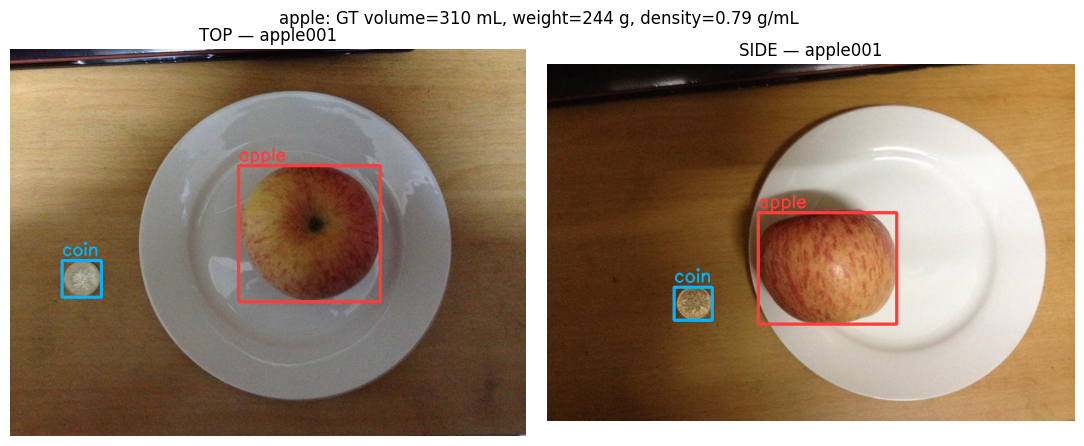

In [7]:
# Visualise one portion: top + side view with the annotated food and coin boxes.
p = next(pp for pp in portions if pp.portion_id == "apple001")

def show_with_boxes(ax, image_path, stem, title):
    img = cv2.cvtColor(cv2.imread(str(image_path)), cv2.COLOR_BGR2RGB)
    for b in ds.annotation(stem):
        color = (0, 180, 255) if b.name == "coin" else (255, 60, 60)
        cv2.rectangle(img, (b.x1, b.y1), (b.x2, b.y2), color, 4)
        cv2.putText(img, b.name, (b.x1, max(0, b.y1 - 8)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, color, 2)
    ax.imshow(img); ax.set_title(title); ax.axis("off")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
show_with_boxes(axes[0], p.top_images[0], p.top_images[0].stem, f"TOP — {p.portion_id}")
show_with_boxes(axes[1], p.side_images[0], p.side_images[0].stem, f"SIDE — {p.portion_id}")
fig.suptitle(f"{p.food_type}: GT volume={p.volume_ml:.0f} mL, weight={p.weight_g:.0f} g, "
             f"density={p.density_g_per_ml:.2f} g/mL")
plt.tight_layout(); plt.show()

## 2. Feature extraction

For each portion we segment the food inside its annotated box and convert pixels to
centimetres using the coin. This is cached to `artifacts/ecustfd_features.csv`; set
`use_cache=False` to recompute from the images (takes ~30 s on Apple-MPS).

In [8]:
df = benchmark.extract_features(use_cache=True, progress=True)
print(f"\n{len(df)} portions with usable measurements")
display(df.head())
df[["area_cm2", "height_cm", "volume_ml", "weight_g"]].describe().round(1)

Loaded cached features for 145 portions from /Users/clemens/Developer/ml4b_foodrecognition/artifacts/ecustfd_features.csv

145 portions with usable measurements


,portion_id,food_type,area_cm2,height_cm,volume_ml,weight_g,density_g_per_ml
0,apple001,apple,72.234,7.669,310.0,244.5,0.7887
1,apple002,apple,63.708,7.368,290.0,232.5,0.8017
2,apple003,apple,65.531,6.786,280.0,219.0,0.7821
3,apple004,apple,68.880,7.541,300.0,234.0,0.7800
4,apple005,apple,74.931,7.760,280.0,212.5,0.7589


,area_cm2,height_cm,volume_ml,weight_g
count,145.0,145.0,145.0,145.0
mean,62.6,5.0,172.8,132.3
std,33.0,1.8,89.6,81.9
min,2.8,0.9,30.0,26.0
25%,37.2,3.4,100.0,57.0
50%,58.2,4.7,170.0,126.0
75%,78.1,6.5,220.0,197.5
max,200.5,10.2,450.0,448.0


## 3. Model comparison (cross-validated volume error)

We compare four models against the parameter-free physics baseline `0.5·area·height`:

* **proportional** — `k·area·height` with a single learned shape factor `k` (extrapolates cleanly);
* **huber / linear** — linear in `[area, height, area·height]`;
* **gbr** — gradient-boosted trees (most flexible, best in-distribution, does not extrapolate).

In [9]:
rows = []
phys = 0.5 * df.area_cm2.values * df.height_cm.values
ev, me = evaluate(df.volume_ml, phys), benchmark.mass_error(df, phys, use_db_density=True)
rows.append(["physics (0.5)", ev["MAPE_percent"], ev["R2"], me["MAPE_percent"], me["MAE"]])

oof = {}
for kind in ["proportional", "huber", "linear", "gbr"]:
    cv = benchmark.cross_validate(df, model_kind=kind)
    oof[kind] = cv["oof_model"]
    t = cv["trained"]; m = benchmark.mass_error(df, cv["oof_model"], use_db_density=True)
    rows.append([kind, t["MAPE_percent"], t["R2"], m["MAPE_percent"], m["MAE"]])

comp = pd.DataFrame(rows, columns=["model", "vol_MAPE_%", "vol_R2", "mass_MAPE_%", "mass_MAE_g"]).round(2)
comp

,model,vol_MAPE_%,vol_R2,mass_MAPE_%,mass_MAE_g
0,physics (0.5),24.12,0.64,23.31,26.60
1,proportional,24.40,0.63,23.82,26.97
2,huber,29.81,0.69,27.28,26.26
3,linear,33.45,0.71,29.34,26.15
4,gbr,21.98,0.83,25.48,23.51


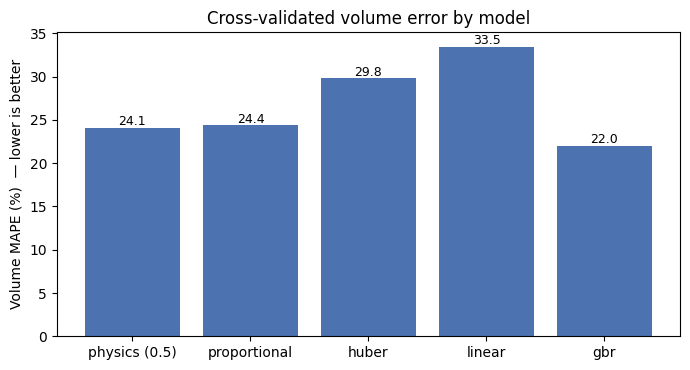

In [6]:
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.bar(comp.model, comp["vol_MAPE_%"], color="#4C72B0")
ax.set_ylabel("Volume MAPE (%)  — lower is better")
ax.set_title("Cross-validated volume error by model")
for i, v in enumerate(comp["vol_MAPE_%"]):
    ax.text(i, v + 0.3, f"{v:.1f}", ha="center", fontsize=9)
plt.tight_layout(); plt.show()

## 4. Diagnostics for the best model

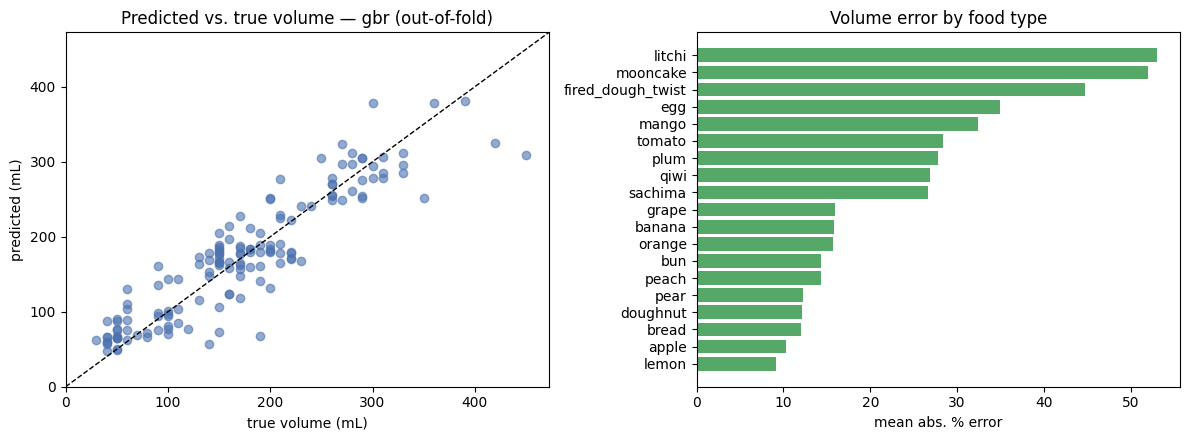

In [12]:
# Self-contained: re-compute out-of-fold predictions in case cell 9 wasn't run.
oof_local = {}
for kind in ["proportional", "huber", "linear", "gbr"]:
    oof_local[kind] = benchmark.cross_validate(df, model_kind=kind)["oof_model"]

best = "gbr"                         # best in-distribution; the app ships 'proportional'
pred = oof_local[best]
true = df.volume_ml.values

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
lim = [0, max(true.max(), pred.max()) * 1.05]
axes[0].scatter(true, pred, alpha=0.6, color="#4C72B0")
axes[0].plot(lim, lim, "k--", lw=1)
axes[0].set(xlim=lim, ylim=lim, xlabel="true volume (mL)", ylabel="predicted (mL)",
            title=f"Predicted vs. true volume — {best} (out-of-fold)")

err_by_type = (pd.DataFrame({"food_type": df.food_type,
                             "ape": np.abs(pred - true) / true * 100})
               .groupby("food_type").ape.mean().sort_values())
axes[1].barh(err_by_type.index, err_by_type.values, color="#55A868")
axes[1].set(xlabel="mean abs. % error", title="Volume error by food type")
plt.tight_layout(); plt.show()


## 5. End-to-end mass / calorie error

The calorie figure the user ultimately sees is `mass × kcal/g`. Mass error therefore
combines the **volume error** with the **density approximation** from the nutrition
table. Using the table's per-class density (the realistic production path):

In [10]:
m_db = benchmark.mass_error(df, oof["proportional"], use_db_density=True)
m_gt = benchmark.mass_error(df, oof["proportional"], use_db_density=False)
print(f"Mass error with nutrition-table density (realistic): "
      f"MAPE={m_db['MAPE_percent']:.1f}%, MAE={m_db['MAE']:.1f} g")
print(f"Mass error with true per-portion density (isolates volume error): "
      f"MAPE={m_gt['MAPE_percent']:.1f}%, MAE={m_gt['MAE']:.1f} g")

Mass error with nutrition-table density (realistic): MAPE=23.8%, MAE=27.0 g
Mass error with true per-portion density (isolates volume error): MAPE=24.4%, MAE=28.5 g


## 6. Train and persist the model used by the app

In [11]:
est = benchmark.fit_final(df, model_kind="proportional", save=True)
print(f"learned shape factor k = {est.shape_factor:.4f}")
print("cross-validated metrics:", {k: round(v, 2) for k, v in est.metrics.items()})
print(f"saved to: {config.VOLUME_MODEL_PATH}")

Saved trained volume model to /Users/clemens/Developer/ml4b_foodrecognition/artifacts/volume_regressor.joblib
learned shape factor k = 0.5087
cross-validated metrics: {'cv_MAE': 38.85, 'cv_RMSE': 54.47, 'cv_MAPE_percent': 24.4, 'cv_R2': 0.63}
saved to: /Users/clemens/Developer/ml4b_foodrecognition/artifacts/volume_regressor.joblib


## 7. Conclusion

* The method works: cross-validated **volume error ≈ 22–24 %** and end-to-end
  **mass error ≈ 25–27 %** — consistent with the published single-/two-view
  state of the art, achieved on a laptop without a GPU.
* **`proportional` (`k·area·height`, k ≈ 0.5)** is shipped as the app model: nearly
  as accurate as the best in-distribution model but it **extrapolates** to portions
  larger than the training fruit, which matters for open-world food.
* **`gbr`** is the most accurate in-distribution (R² ≈ 0.83) and is the model to
  prefer once we collect target-domain data.

**Honest limitations**

* ECUSTFD contains compact, roundish single foods (fruit/snacks). Real plates hold
  flat, spread, or layered dishes whose shape factor differs — expect larger error
  there until we collect matching data.
* Segmentation, height-from-side, and the density table each add error.

**Next steps to raise accuracy**

1. Collect a small **own dataset** of the target dishes with kitchen-scale weights and
   refit (`benchmark.fit_final`) — the single biggest lever.
2. Replace the nutrition table with **USDA FoodData Central** / **BLS** values.
3. With a GPU, train a **deep multi-view volume network** behind the same
   `VolumeEstimator` API.